# 第八章配套实验：拟牛顿法如何学习曲率

这个 Notebook 配合“拟牛顿法”课件使用，重点观察四件事：

1. 为什么位移 $s_k$ 和梯度差 $y_k$ 能携带曲率信息；
2. BFGS 如何在不计算 Hessian 的情况下逐步改善方向；
3. 在 Rosenbrock 函数上，GD、Newton、BFGS 的迭代行为有何差异；
4. L-BFGS 如何用有限历史信息处理较高维问题。

课堂建议：先运行公共函数，再依次运行实验 1 到实验 4。每个实验前面的说明都给出了要观察的数学现象。

In [3]:
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PICS = BASE / "pics"
PICS.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]

SHANSHU = "#841e34"
BLUE = "#46445D"
DEEP_GREEN = "#0A6B3A"
ORANGE = "#AC7088"
HALF_GRAY = "0.55"

summaries = []


def timed_run(fn, repeats=1):
    start = perf_counter()
    result = None
    for _ in range(repeats):
        result = fn()
    return result, (perf_counter() - start) / repeats


def add_summary(experiment, method, iterations, runtime, final_loss, note=""):
    summaries.append({
        "experiment": experiment,
        "method": method,
        "iterations": iterations,
        "runtime_sec": runtime,
        "final_loss": final_loss,
        "note": note,
    })


def armijo_backtracking(f, grad, x, d, c=1e-4, beta=0.5, min_alpha=1e-12):
    g = grad(x)
    gd = float(g @ d)
    if gd >= 0:
        return 0.0
    alpha = 1.0
    fx = f(x)
    while f(x + alpha * d) > fx + c * alpha * gd and alpha > min_alpha:
        alpha *= beta
    return alpha

print(f"图片会保存到: {PICS}")

图片会保存到: c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics


## 实验 1：割线条件为什么合理

考虑严格凸二次函数

$$
f(x)=\frac12x^TQx,
\qquad
Q=\begin{pmatrix}8&0\\0&1\end{pmatrix}.
$$

它的梯度为

$$
\nabla f(x)=Qx.
$$

因此任意两点 $x^k,x^{k+1}$ 之间都有

$$
y_k=\nabla f(x^{k+1})-\nabla f(x^k)=Q(x^{k+1}-x^k)=Qs_k.
$$

这说明：对二次函数，割线条件 $B_{k+1}s_k=y_k$ 如果取 $B_{k+1}=Q$ 就是精确成立的。

本实验随机选几组移动方向 $s_k$，观察 $y_k$ 如何反映不同方向的曲率。特别看数量

$$
\frac{y_k^Ts_k}{s_k^Ts_k},
$$

它可以理解为沿方向 $s_k$ 的平均曲率。

,s_k,y_k = Q s_k,y^T s,average curvature
0,"[1.0, 0.0]","[8.0, 0.0]",8.0,8.0
1,"[0.0, 1.0]","[0.0, 1.0]",1.0,1.0
2,"[1.0, 1.0]","[8.0, 1.0]",9.0,4.5
3,"[1.0, -2.0]","[8.0, -2.0]",12.0,2.4
4,"[2.0, 1.0]","[16.0, 1.0]",33.0,6.6


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_quasi_newton_secant_condition.png


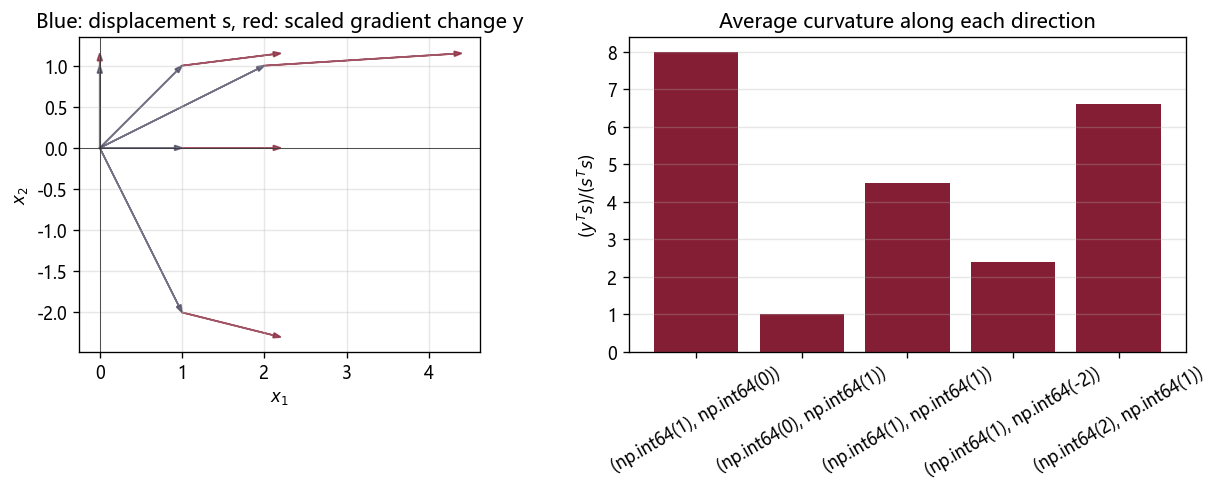

In [4]:
Q2 = np.diag([8.0, 1.0])
directions = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
    [1.0, -2.0],
    [2.0, 1.0],
])

rows = []
for s in directions:
    y = Q2 @ s
    avg_curv = float(y @ s) / float(s @ s)
    rows.append({
        "s_k": s,
        "y_k = Q s_k": y,
        "y^T s": float(y @ s),
        "average curvature": avg_curv,
    })
secant_table = pd.DataFrame(rows)
display(secant_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
origin = np.zeros(2)
for s in directions:
    y = Q2 @ s
    axes[0].arrow(0, 0, s[0], s[1], head_width=0.06, length_includes_head=True, color=BLUE, alpha=0.75)
    axes[0].arrow(s[0], s[1], 0.15 * y[0], 0.15 * y[1], head_width=0.06, length_includes_head=True, color=SHANSHU, alpha=0.75)
axes[0].set_aspect("equal", adjustable="box")
axes[0].axhline(0, color="0.2", linewidth=0.5)
axes[0].axvline(0, color="0.2", linewidth=0.5)
axes[0].set_title("Blue: displacement s, red: scaled gradient change y")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
axes[0].grid(alpha=0.3)

axes[1].bar(range(len(rows)), [r["average curvature"] for r in rows], color=SHANSHU)
axes[1].set_xticks(range(len(rows)))
axes[1].set_xticklabels([str(tuple(s.astype(int))) for s in directions], rotation=30)
axes[1].set_ylabel(r"$(y^Ts)/(s^Ts)$")
axes[1].set_title("Average curvature along each direction")
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_quasi_newton_secant_condition.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 2：BFGS 如何逐步学习逆 Hessian

还是考虑二次函数

$$
f(x)=\frac12x^TQx,
\qquad Q\succ0.
$$

真实 Newton 方向是

$$
d_N=-Q^{-1}\nabla f(x).
$$

BFGS 不知道 $Q^{-1}$，而是从 $H_0=I$ 开始，通过每一步的

$$
s_k=x^{k+1}-x^k,
\qquad
y_k=g_{k+1}-g_k
$$

更新 $H_k$。如果 $H_k$ 越来越接近 $Q^{-1}$，那么 BFGS 方向就会越来越接近 Newton 方向。

本实验在一个二维二次函数上记录 $\|H_k-Q^{-1}\|_F$ 的变化，并比较 GD 与 BFGS 的 loss 曲线。

,k,f_BFGS,||H_k-Q^{-1}||_F
0,0,9.925000e+01,1.107143
1,1,1.744653e+01,0.559781
2,2,6.360580e-01,0.418155
3,3,5.198885e-02,0.006287
4,4,8.098734e-05,0.013130
5,5,2.317697e-07,0.022705
6,6,1.287363e-11,0.015898
7,7,1.264526e-15,0.000268
8,8,2.424206e-21,0.000268


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_quasi_newton_bfgs_learns_hessian.png


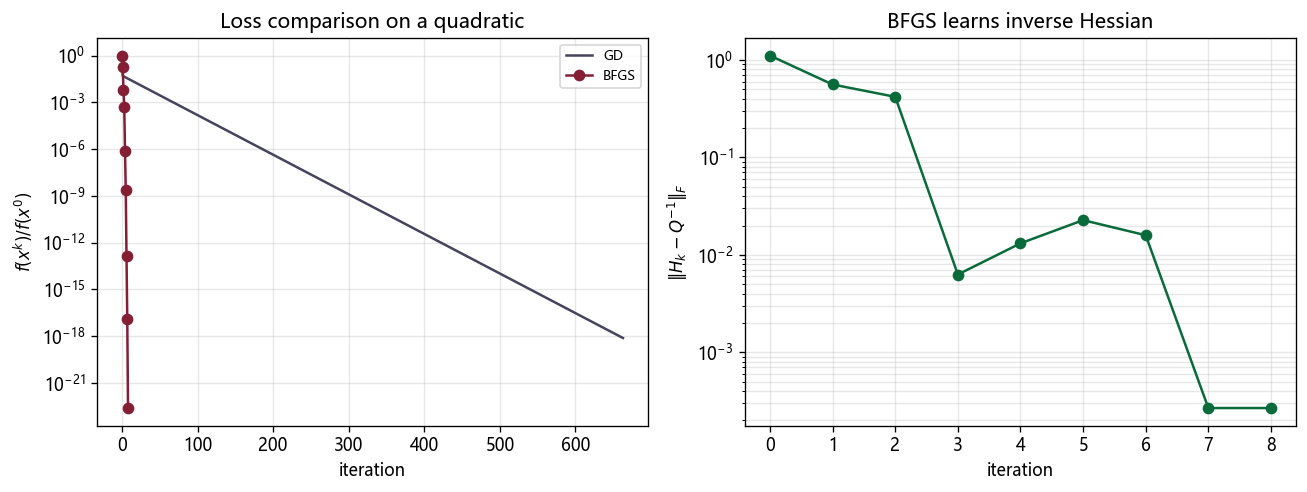

In [5]:
def quad_make(Q):
    def f(x):
        return 0.5 * float(x @ Q @ x)

    def grad(x):
        return Q @ x

    return f, grad


def bfgs_full(f, grad, x0, max_iter=80, tol=1e-8):
    x = np.array(x0, dtype=float)
    n = x.size
    H = np.eye(n)
    xs = [x.copy()]
    fs = [f(x)]
    Hs = [H.copy()]
    skipped = 0
    for k in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            break
        d = -H @ g
        if float(g @ d) >= 0:
            d = -g
        alpha = armijo_backtracking(f, grad, x, d)
        if alpha == 0.0:
            break
        x_new = x + alpha * d
        s = x_new - x
        y = grad(x_new) - g
        ys = float(y @ s)
        if ys > 1e-12:
            rho = 1.0 / ys
            I = np.eye(n)
            V = I - rho * np.outer(s, y)
            H = V @ H @ V.T + rho * np.outer(s, s)
        else:
            skipped += 1
        x = x_new
        xs.append(x.copy())
        fs.append(f(x))
        Hs.append(H.copy())
    return np.array(xs), np.array(fs), Hs, skipped


def gd_fixed(f, grad, x0, alpha, max_iter=2000, tol=1e-8):
    x = np.array(x0, dtype=float)
    xs = [x.copy()]
    fs = [f(x)]
    for k in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            break
        x = x - alpha * g
        xs.append(x.copy())
        fs.append(f(x))
    return np.array(xs), np.array(fs)

Q = np.array([[20.0, 6.0], [6.0, 2.5]])
fq, gq = quad_make(Q)
Q_inv = np.linalg.inv(Q)
x0 = np.array([4.0, -3.0])

(xs_bfgs, fs_bfgs, Hs, skipped), t_bfgs = timed_run(lambda: bfgs_full(fq, gq, x0), repeats=20)
(xs_gd, fs_gd), t_gd = timed_run(lambda: gd_fixed(fq, gq, x0, alpha=0.045), repeats=5)
H_errors = [np.linalg.norm(H - Q_inv, ord="fro") for H in Hs]

learn_table = pd.DataFrame({
    "k": range(len(H_errors)),
    "f_BFGS": fs_bfgs,
    "||H_k-Q^{-1}||_F": H_errors,
})
display(learn_table.head(12))

add_summary("quadratic learning", "GD", len(fs_gd)-1, t_gd, fs_gd[-1])
add_summary("quadratic learning", "BFGS", len(fs_bfgs)-1, t_bfgs, fs_bfgs[-1], f"skipped={skipped}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].semilogy(fs_gd / fs_gd[0], color=BLUE, label="GD")
axes[0].semilogy(fs_bfgs / fs_bfgs[0], "o-", color=SHANSHU, label="BFGS")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel(r"$f(x^k)/f(x^0)$")
axes[0].set_title("Loss comparison on a quadratic")
axes[0].legend(fontsize=8)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(H_errors, "o-", color=DEEP_GREEN)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel(r"$\|H_k-Q^{-1}\|_F$")
axes[1].set_title("BFGS learns inverse Hessian")
axes[1].grid(True, which="both", alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_quasi_newton_bfgs_learns_hessian.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 3：Rosenbrock 函数上的 GD、Newton 与 BFGS

Rosenbrock 函数是优化算法中常用的测试函数：

$$
f(x_1,x_2)=100(x_2-x_1^2)^2+(1-x_1)^2.
$$

它的全局最小点是

$$
x^\star=(1,1)^T,
\qquad f(x^\star)=0.
$$

这个函数的难点在于：最优点附近有一条弯曲而狭长的“谷底”。GD 沿负梯度方向走，容易在谷底两侧慢慢挪；Newton 使用真实 Hessian，方向质量高，但每步要计算和求解 Hessian；BFGS 不计算 Hessian，而是逐步学习曲率。

本实验比较三种方法的迭代轨迹、loss 曲线和迭代次数。

,method,iterations,runtime_sec,final_loss
0,GD,20000,0.281574,1.938492e-08
1,Newton,21,0.002222,3.743976e-21
2,BFGS,34,0.002775,2.745638e-17


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_quasi_newton_rosenbrock_paths.png
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_quasi_newton_rosenbrock_loss.png


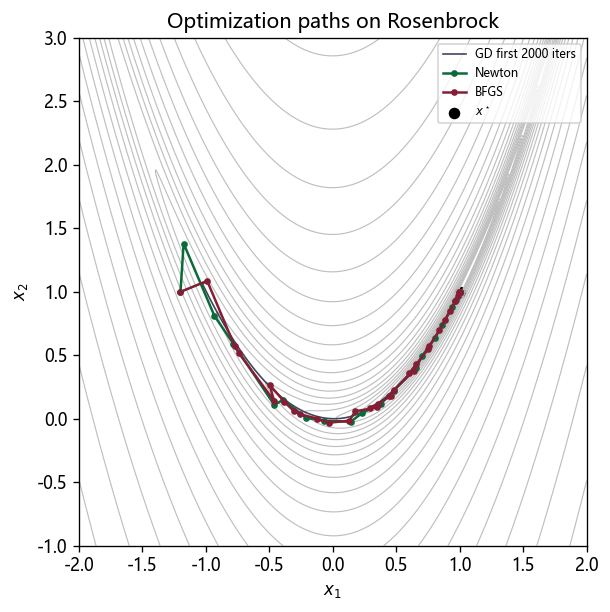

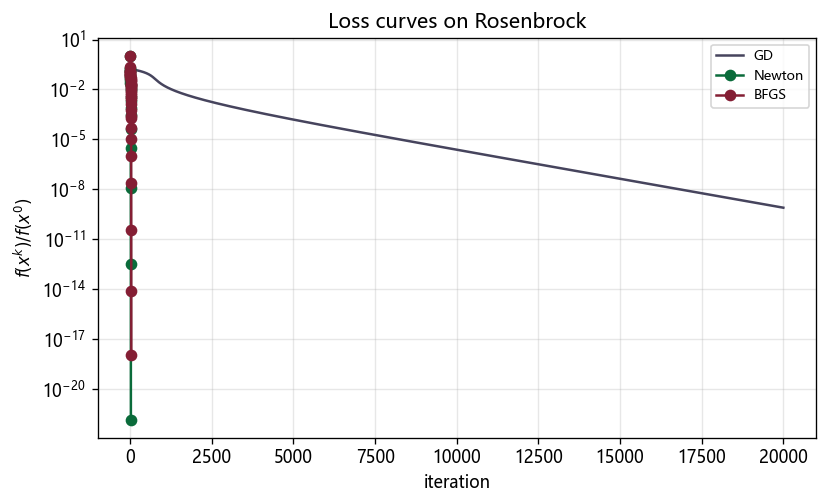

In [6]:
def rosenbrock(x):
    x1, x2 = x
    return 100 * (x2 - x1**2)**2 + (1 - x1)**2


def rosen_grad(x):
    x1, x2 = x
    return np.array([
        -400 * x1 * (x2 - x1**2) - 2 * (1 - x1),
        200 * (x2 - x1**2),
    ])


def rosen_hess(x):
    x1, x2 = x
    return np.array([
        [1200 * x1**2 - 400 * x2 + 2, -400 * x1],
        [-400 * x1, 200],
    ])


def newton_rosen(x0, max_iter=80, tol=1e-8):
    x = np.array(x0, dtype=float)
    xs = [x.copy()]
    fs = [rosenbrock(x)]
    for k in range(max_iter):
        g = rosen_grad(x)
        if np.linalg.norm(g) <= tol:
            break
        H = rosen_hess(x)
        try:
            d = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            d = -g
        if float(g @ d) >= 0:
            d = -g
        alpha = armijo_backtracking(rosenbrock, rosen_grad, x, d)
        if alpha == 0.0:
            break
        x = x + alpha * d
        xs.append(x.copy())
        fs.append(rosenbrock(x))
    return np.array(xs), np.array(fs)


def plot_rosen_contours(ax, xlim=(-2.0, 2.0), ylim=(-1.0, 3.0), levels=None):
    if levels is None:
        levels = np.logspace(-1, 3.5, 24)
    xgrid = np.linspace(xlim[0], xlim[1], 450)
    ygrid = np.linspace(ylim[0], ylim[1], 450)
    X, Y = np.meshgrid(xgrid, ygrid)
    Z = 100 * (Y - X**2)**2 + (1 - X)**2
    ax.contour(X, Y, Z, levels=levels, colors="0.75", linewidths=0.7)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

x0 = np.array([-1.2, 1.0])
(xs_gd_ros, fs_gd_ros), t_gd_ros = timed_run(lambda: gd_fixed(rosenbrock, rosen_grad, x0, alpha=1e-3, max_iter=20000, tol=1e-6), repeats=1)
(xs_nt_ros, fs_nt_ros), t_nt_ros = timed_run(lambda: newton_rosen(x0, tol=1e-6), repeats=20)
(xs_bfgs_ros, fs_bfgs_ros, _, skipped_ros), t_bfgs_ros = timed_run(lambda: bfgs_full(rosenbrock, rosen_grad, x0, max_iter=200, tol=1e-6), repeats=10)

ros_table = pd.DataFrame([
    {"method": "GD", "iterations": len(fs_gd_ros)-1, "runtime_sec": t_gd_ros, "final_loss": fs_gd_ros[-1]},
    {"method": "Newton", "iterations": len(fs_nt_ros)-1, "runtime_sec": t_nt_ros, "final_loss": fs_nt_ros[-1]},
    {"method": "BFGS", "iterations": len(fs_bfgs_ros)-1, "runtime_sec": t_bfgs_ros, "final_loss": fs_bfgs_ros[-1]},
])
display(ros_table)
for _, row in ros_table.iterrows():
    add_summary("Rosenbrock", row["method"], row["iterations"], row["runtime_sec"], row["final_loss"])

fig_path, ax_path = plt.subplots(figsize=(6.0, 5.2))
plot_rosen_contours(ax_path)
ax_path.plot(xs_gd_ros[:2000, 0], xs_gd_ros[:2000, 1], color=BLUE, linewidth=1.0, label="GD first 2000 iters")
ax_path.plot(xs_nt_ros[:, 0], xs_nt_ros[:, 1], "o-", color=DEEP_GREEN, markersize=3, label="Newton")
ax_path.plot(xs_bfgs_ros[:, 0], xs_bfgs_ros[:, 1], "o-", color=SHANSHU, markersize=3, label="BFGS")
ax_path.scatter([1], [1], color="black", s=35, label=r"$x^\star$")
ax_path.set_title("Optimization paths on Rosenbrock")
ax_path.legend(fontsize=7)
fig_path.tight_layout()
out_path = PICS / "chapter8_quasi_newton_rosenbrock_paths.png"
fig_path.savefig(out_path, bbox_inches="tight")

fig_loss, ax_loss = plt.subplots(figsize=(7.0, 4.3))
ax_loss.semilogy(fs_gd_ros / fs_gd_ros[0], color=BLUE, label="GD")
ax_loss.semilogy(fs_nt_ros / fs_nt_ros[0], "o-", color=DEEP_GREEN, label="Newton")
ax_loss.semilogy(fs_bfgs_ros / fs_bfgs_ros[0], "o-", color=SHANSHU, label="BFGS")
ax_loss.set_xlabel("iteration")
ax_loss.set_ylabel(r"$f(x^k)/f(x^0)$")
ax_loss.set_title("Loss curves on Rosenbrock")
ax_loss.grid(True, which="both", alpha=0.3)
ax_loss.legend(fontsize=8)
fig_loss.tight_layout()
out_loss = PICS / "chapter8_quasi_newton_rosenbrock_loss.png"
fig_loss.savefig(out_loss, bbox_inches="tight")

print(f"saved to {out_path}")
print(f"saved to {out_loss}")

## 实验 4：L-BFGS 的有限记忆效果

BFGS 需要保存完整矩阵 $H_k\in\mathbb{R}^{n\times n}$。当 $n$ 很大时，这会带来明显的存储压力。

L-BFGS 不保存完整矩阵，而是只保存最近 $m$ 组

$$
(s_i,y_i).
$$

方向 $d^k=-H_kg_k$ 通过 two-loop recursion 间接计算。

本实验构造一个较高维的病态二次函数

$$
f(x)=\frac12x^TQx,
$$

其中 $Q$ 的特征值从 1 到 1000。我们比较固定步长 GD 与不同记忆长度 $m$ 的 L-BFGS。观察重点：有限记忆越多，曲率信息越充分，但每步计算和存储也略增。

,method,memory,iterations,runtime_sec,final_loss
0,GD,0,5000,0.124402,1.839414e-05
1,L-BFGS,3,274,0.029123,8.968999e-12
2,L-BFGS,10,259,0.048814,1.102247e-11
3,L-BFGS,20,232,0.065934,4.962812e-12


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_quasi_newton_lbfgs_memory.png


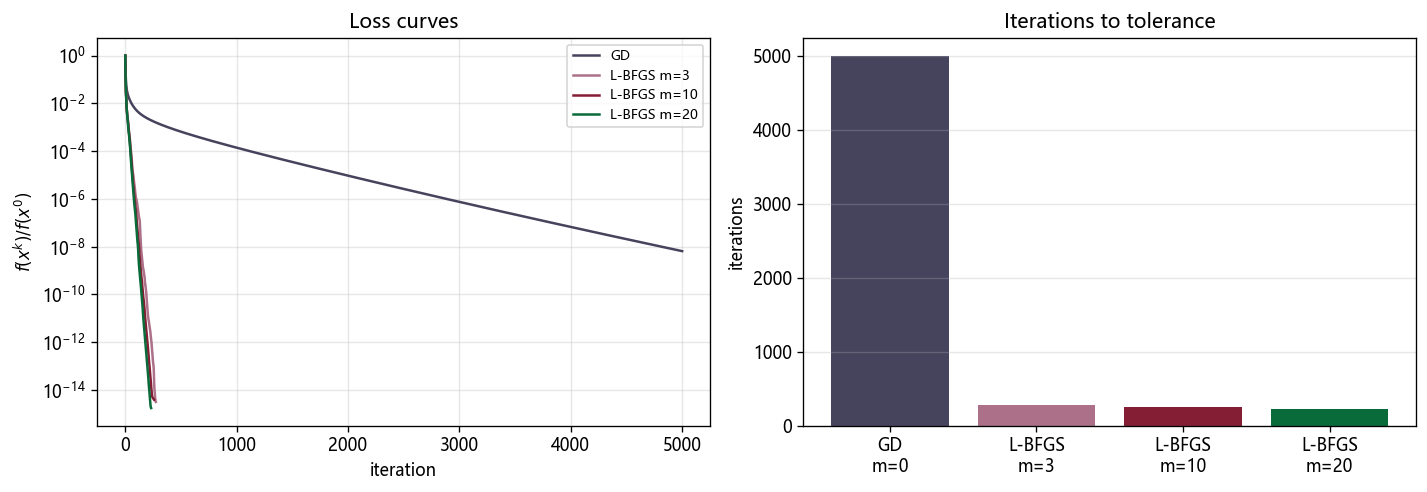

In [7]:
def lbfgs_direction(g, s_hist, y_hist):
    if not s_hist:
        return -g
    q = g.copy()
    alphas = []
    rhos = []
    for s, y in zip(reversed(s_hist), reversed(y_hist)):
        rho = 1.0 / float(y @ s)
        alpha = rho * float(s @ q)
        q = q - alpha * y
        alphas.append(alpha)
        rhos.append(rho)

    s_last, y_last = s_hist[-1], y_hist[-1]
    gamma = float(s_last @ y_last) / float(y_last @ y_last)
    r = gamma * q

    for s, y, alpha, rho in zip(s_hist, y_hist, reversed(alphas), reversed(rhos)):
        beta = rho * float(y @ r)
        r = r + s * (alpha - beta)
    return -r


def lbfgs(f, grad, x0, memory=10, max_iter=500, tol=1e-6):
    x = np.array(x0, dtype=float)
    s_hist, y_hist = [], []
    xs = [x.copy()]
    fs = [f(x)]
    skipped = 0
    for k in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            break
        d = lbfgs_direction(g, s_hist, y_hist)
        if float(g @ d) >= 0:
            d = -g
        alpha = armijo_backtracking(f, grad, x, d)
        if alpha == 0.0:
            break
        x_new = x + alpha * d
        s = x_new - x
        y = grad(x_new) - g
        if float(s @ y) > 1e-12:
            s_hist.append(s)
            y_hist.append(y)
            if len(s_hist) > memory:
                s_hist.pop(0)
                y_hist.pop(0)
        else:
            skipped += 1
        x = x_new
        xs.append(x.copy())
        fs.append(f(x))
    return np.array(xs), np.array(fs), skipped

n = 80
eigvals = np.logspace(0, 3, n)
Q_hd = np.diag(eigvals)
f_hd, g_hd = quad_make(Q_hd)
rng = np.random.default_rng(42)
x0_hd = rng.normal(size=n)
alpha_gd = 1.0 / eigvals.max()

rows = []
(gd_hd, fs_gd_hd), t_gd_hd = timed_run(lambda: gd_fixed(f_hd, g_hd, x0_hd, alpha=alpha_gd, max_iter=5000, tol=1e-5), repeats=1)
rows.append({"method": "GD", "memory": 0, "iterations": len(fs_gd_hd)-1, "runtime_sec": t_gd_hd, "final_loss": fs_gd_hd[-1]})

loss_curves = [("GD", fs_gd_hd / fs_gd_hd[0], BLUE)]
for memory, color in [(3, ORANGE), (10, SHANSHU), (20, DEEP_GREEN)]:
    (xs_lb, fs_lb, skipped), runtime = timed_run(lambda m=memory: lbfgs(f_hd, g_hd, x0_hd, memory=m, max_iter=500, tol=1e-5), repeats=3)
    rows.append({"method": "L-BFGS", "memory": memory, "iterations": len(fs_lb)-1, "runtime_sec": runtime, "final_loss": fs_lb[-1]})
    loss_curves.append((f"L-BFGS m={memory}", fs_lb / fs_lb[0], color))

lbfgs_table = pd.DataFrame(rows)
display(lbfgs_table)
for _, row in lbfgs_table.iterrows():
    add_summary("high-dimensional quadratic", f"{row['method']} m={row['memory']}", row["iterations"], row["runtime_sec"], row["final_loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for label, rel, color in loss_curves:
    axes[0].semilogy(rel, color=color, label=label)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel(r"$f(x^k)/f(x^0)$")
axes[0].set_title("Loss curves")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)

labels = [f"{r.method}\nm={int(r.memory)}" for r in lbfgs_table.itertuples()]
axes[1].bar(labels, lbfgs_table["iterations"], color=[BLUE, ORANGE, SHANSHU, DEEP_GREEN])
axes[1].set_ylabel("iterations")
axes[1].set_title("Iterations to tolerance")
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_quasi_newton_lbfgs_memory.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 5：实验总结

前面几个实验对应 PPT 中的主要结论：

1. 割线条件来自 $y_k\approx \nabla^2 f(x)s_k$，在二次函数上可以精确成立；
2. BFGS 通过 $s_k,y_k$ 逐步改进 $H_k$，方向质量通常优于 GD；
3. 在弯曲谷底问题上，BFGS 能在不计算 Hessian 的情况下接近 Newton 的效果；
4. L-BFGS 用有限历史信息换取低存储，是大规模光滑优化中常用的实践版本。

这一节汇总不同实验中的迭代次数和 runtime。和前面的 Newton 实验一样，小规模 Python runtime 只作参考，更重要的是观察不同算法随问题结构变化的行为。

,experiment,method,iterations,runtime_sec,final_loss,note
0,Rosenbrock,BFGS,34,0.002775,2.745638e-17,
1,Rosenbrock,GD,20000,0.281574,1.938492e-08,
2,Rosenbrock,Newton,21,0.002222,3.743976e-21,
3,high-dimensional quadratic,GD m=0,5000,0.124402,1.839414e-05,
4,high-dimensional quadratic,L-BFGS m=10,259,0.048814,1.102247e-11,
5,high-dimensional quadratic,L-BFGS m=20,232,0.065934,4.962812e-12,
6,high-dimensional quadratic,L-BFGS m=3,274,0.029123,8.968999e-12,
7,quadratic learning,BFGS,8,0.001304,2.424206e-21,skipped=1
8,quadratic learning,GD,663,0.011927,7.577479e-17,


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_quasi_newton_summary.png


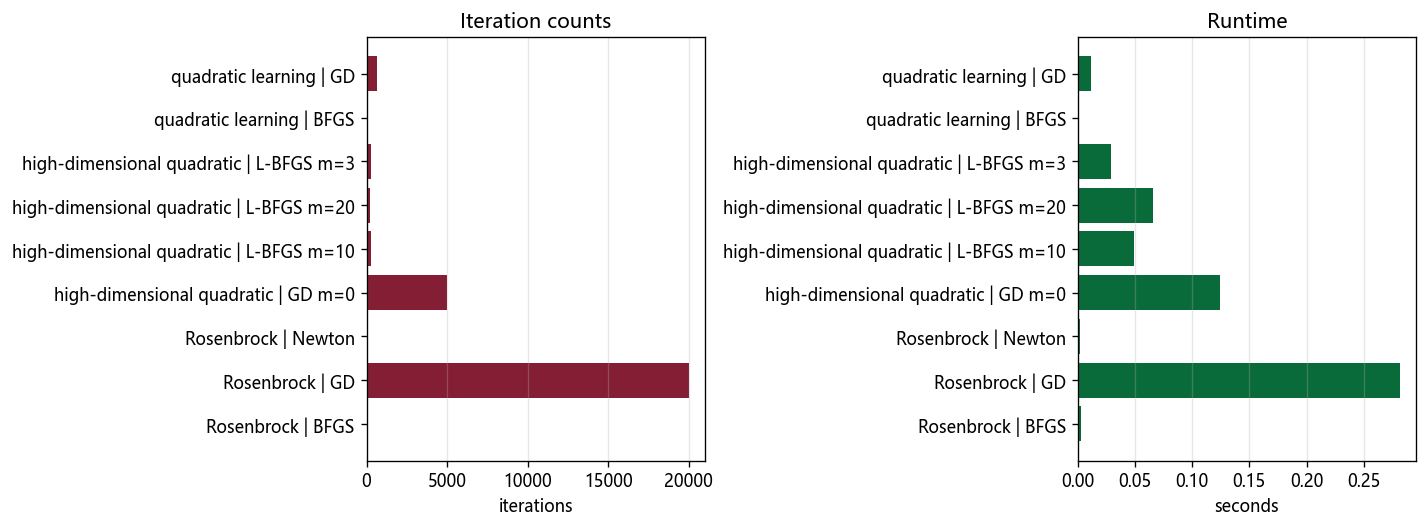

In [8]:
summary_df = pd.DataFrame(summaries)
summary_df = summary_df.sort_values(["experiment", "method"]).reset_index(drop=True)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_df = summary_df.dropna(subset=["iterations"]).copy()
plot_df["label"] = plot_df["experiment"] + " | " + plot_df["method"]
axes[0].barh(plot_df["label"], plot_df["iterations"], color=SHANSHU)
axes[0].set_xlabel("iterations")
axes[0].set_title("Iteration counts")
axes[0].grid(axis="x", alpha=0.3)

runtime_df = summary_df.dropna(subset=["runtime_sec"]).copy()
runtime_df["label"] = runtime_df["experiment"] + " | " + runtime_df["method"]
axes[1].barh(runtime_df["label"], runtime_df["runtime_sec"], color=DEEP_GREEN)
axes[1].set_xlabel("seconds")
axes[1].set_title("Runtime")
axes[1].grid(axis="x", alpha=0.3)
fig.tight_layout()
out = PICS / "chapter8_quasi_newton_summary.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")